In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

In [3]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

In [4]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier

In [5]:
import spacy

In [6]:
# Load the dataset
data = pd.read_csv("train.csv")

In [7]:
# Display basic information and the first few rows of the dataset
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB
None
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  


In [8]:
# Analyzing the distribution of the target variable
target_distribution = data["target"].value_counts(normalize=True)
print("Distribution of target variable:\n", target_distribution)

Distribution of target variable:
 target
0    0.57034
1    0.42966
Name: proportion, dtype: float64


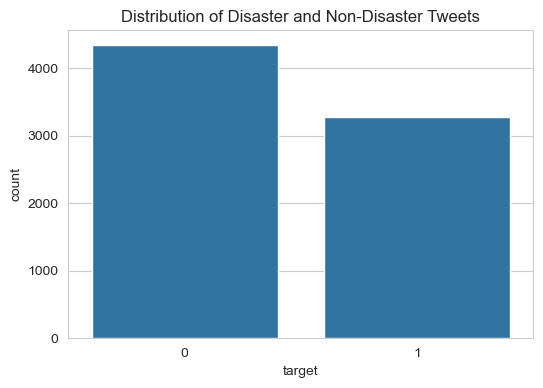

In [9]:
# Visualizing the target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=data)
plt.title("Distribution of Disaster and Non-Disaster Tweets")
plt.show()

In [10]:
# Checking for missing values
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


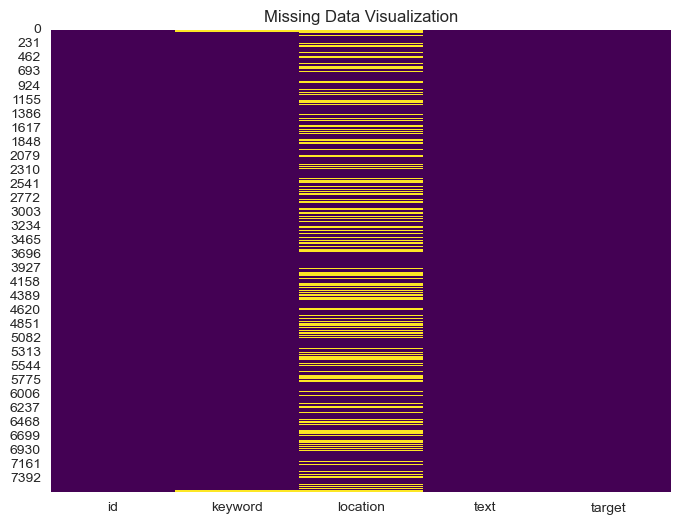

In [11]:
# Visualizing missing values
plt.figure(figsize=(8, 6))
sns.heatmap(data.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Visualization")
plt.show()

In [12]:
# Basic text analysis: average length of tweets and common words
data["tweet_length"] = data["text"].apply(len)
average_tweet_length = data["tweet_length"].mean()
print("Average tweet length:", average_tweet_length)

Average tweet length: 101.03743596479706


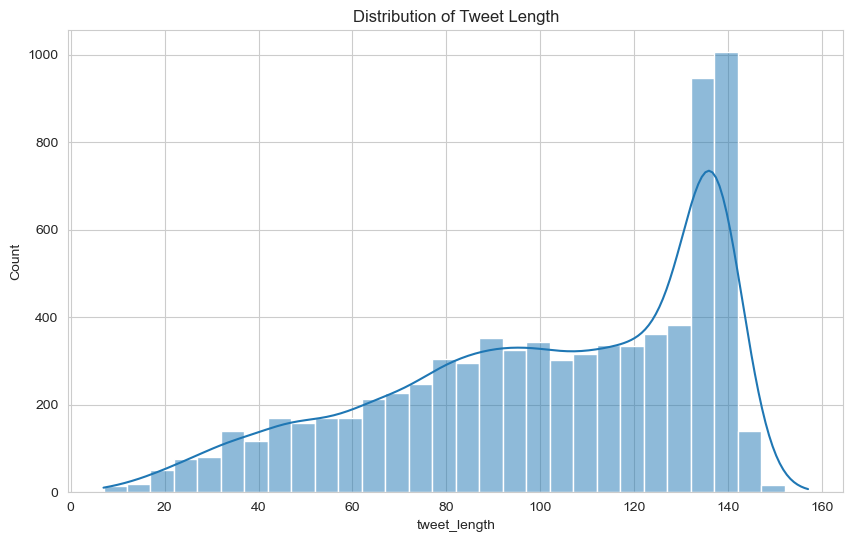

In [13]:
# Visualizing tweet length distribution
plt.figure(figsize=(10, 6))
sns.histplot(data["tweet_length"], bins=30, kde=True)
plt.title("Distribution of Tweet Length")
plt.show()

In [14]:
# Keyword analysis
print("Top 10 common keywords:\n", data["keyword"].value_counts().head(10))

Top 10 common keywords:
 keyword
fatalities     45
deluge         42
armageddon     42
sinking        41
damage         41
harm           41
body%20bags    41
outbreak       40
evacuate       40
fear           40
Name: count, dtype: int64


In [15]:
# Location analysis
print("Top 10 tweet locations:\n", data["location"].value_counts().head(10))

Top 10 tweet locations:
 location
USA                104
New York            71
United States       50
London              45
Canada              29
Nigeria             28
UK                  27
Los Angeles, CA     26
India               24
Mumbai              22
Name: count, dtype: int64


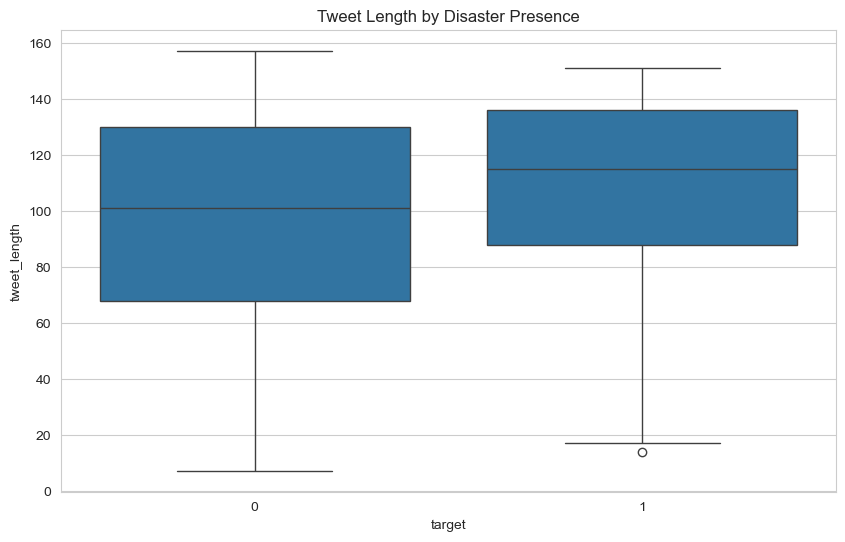

In [17]:
# Correlation between tweet length and target
sns.set_color_codes("pastel")
plt.style.use()
plt.figure(figsize=(10, 6))
sns.boxplot(x="target", y="tweet_length", data=data)
plt.title("Tweet Length by Disaster Presence")
plt.show()

In [13]:
# Advanced: Word Frequency Analysis
vectorizer = CountVectorizer(stop_words="english", max_features=100)
word_matrix = vectorizer.fit_transform(data["text"])
sum_words = word_matrix.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
print("Most common words:\n", words_freq[:10])

Most common words:
 [('http', 4309), ('https', 411), ('like', 348), ('û_', 348), ('amp', 344), ('just', 323), ('new', 226), ('people', 200), ('news', 197), ('don', 190)]


In [20]:
# Load SpaCy's English-language model
nlp = spacy.load("en_core_web_sm")

In [21]:
# Define the text cleaning function using SpaCy
def clean_text_spacy(text):
    doc = nlp(text)
    tokens = []
    for token in doc:
        if token.is_alpha and not token.is_stop:
            tokens.append(token.lemma_.lower())
    return " ".join(tokens)

In [22]:
# Apply cleaning function to the dataset
data["text_clean"] = data["text"].apply(clean_text_spacy)

In [23]:
# Feature Engineering with TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)  # Limit number of features to 5000 for simplicity
X = tfidf_vectorizer.fit_transform(data["text_clean"])
y = data["target"]

In [24]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Setting up Optimization

In [43]:
!pip install scikit-optimize

In [44]:
from skopt import BayesSearchCV

### Logistic Regression

In [25]:
# Training the Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [26]:
# Predicting on test data
y_pred = model.predict(X_test)

In [27]:
# Evaluating the model
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy on Test Set: 0.7964543663821405
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.89      0.83       874
           1       0.82      0.67      0.74       649

    accuracy                           0.80      1523
   macro avg       0.80      0.78      0.79      1523
weighted avg       0.80      0.80      0.79      1523

Confusion Matrix:
 [[777  97]
 [213 436]]


In [46]:
# Define parameter space
param_space = {"C": (1e-6, 1000, "log-uniform"), "penalty": ["l2"]}

# Setup Bayesian optimization
opt = BayesSearchCV(LogisticRegression(), param_space, n_iter=32, random_state=0, cv=3)

opt.fit(X_train, y_train)
print("Best parameters: ", opt.best_params_)

/opt/anaconda3/envs/metal/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/envs/metal/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logis

Best parameters:  OrderedDict([('C', 1.1432443711232225), ('penalty', 'l2')])


In [47]:
# Initialize Logistic Regression with the best parameters
best_params = {"C": 1.1432443711232225, "penalty": "l2"}
logreg = LogisticRegression(
    **best_params, max_iter=1000
)  # Add any additional arguments as needed

# Fit the model to your data
logreg.fit(X_train, y_train)

# Make predictions on the test data
y_pred = logreg.predict(X_test)

# Evaluating the model
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy on Test Set: 0.7997373604727511
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.89      0.84       874
           1       0.82      0.68      0.74       649

    accuracy                           0.80      1523
   macro avg       0.80      0.78      0.79      1523
weighted avg       0.80      0.80      0.80      1523

Confusion Matrix:
 [[777  97]
 [208 441]]


### Naive Bayes Classifier

In [30]:
# Create and train the Naive Bayes classifier
naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train, y_train)

# Predicting on the test data
y_pred = naive_bayes_model.predict(X_test)

# Evaluating the model
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy on Test Set: 0.7984241628365069
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83       874
           1       0.81      0.69      0.74       649

    accuracy                           0.80      1523
   macro avg       0.80      0.78      0.79      1523
weighted avg       0.80      0.80      0.80      1523

Confusion Matrix:
 [[768 106]
 [201 448]]


In [48]:
param_space = {"alpha": (1e-4, 10, "log-uniform")}

opt = BayesSearchCV(MultinomialNB(), param_space, n_iter=32, random_state=0, cv=3)

opt.fit(X_train, y_train)
print("Best parameters: ", opt.best_params_)

Best parameters:  OrderedDict([('alpha', 1.551786297860205)])


In [49]:
# Initialize Naive Bayes with the best parameter
best_alpha = 1.551786297860205
nb = MultinomialNB(alpha=best_alpha)

# Fit the model to your data
nb.fit(X_train, y_train)

# Make predictions on the test data
y_pred = nb.predict(X_test)

# Evaluating the model
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy on Test Set: 0.793827971109652
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.88      0.83       874
           1       0.81      0.67      0.74       649

    accuracy                           0.79      1523
   macro avg       0.80      0.78      0.78      1523
weighted avg       0.80      0.79      0.79      1523

Confusion Matrix:
 [[772 102]
 [212 437]]


### Random Forest

In [32]:
# Create and train the Random Forest classifier
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

# Predicting on the test data
y_pred = random_forest_model.predict(X_test)

# Evaluating the model
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy on Test Set: 0.7787261982928431
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.85      0.82       874
           1       0.77      0.68      0.72       649

    accuracy                           0.78      1523
   macro avg       0.78      0.77      0.77      1523
weighted avg       0.78      0.78      0.78      1523

Confusion Matrix:
 [[745 129]
 [208 441]]


In [50]:
param_space = {
    "n_estimators": (10, 300),
    "max_depth": (3, 50),
    "min_samples_split": (2, 25),
}

opt = BayesSearchCV(
    RandomForestClassifier(), param_space, n_iter=32, random_state=0, cv=3
)

opt.fit(X_train, y_train)
print("Best parameters: ", opt.best_params_)

Best parameters:  OrderedDict([('max_depth', 50), ('min_samples_split', 23), ('n_estimators', 297)])


In [51]:
# Initialize Random Forest with the best parameters
best_params = {"max_depth": 50, "min_samples_split": 23, "n_estimators": 297}
rf = RandomForestClassifier(**best_params)

# Fit the model to your data
rf.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf.predict(X_test)

# Evaluating the model
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy on Test Set: 0.7590282337491793
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.94      0.82       874
           1       0.87      0.51      0.65       649

    accuracy                           0.76      1523
   macro avg       0.79      0.73      0.73      1523
weighted avg       0.78      0.76      0.74      1523

Confusion Matrix:
 [[822  52]
 [315 334]]


### Adaptive Boost

In [38]:
ada_model = AdaBoostClassifier()
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)
# print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.85      0.82       874
           1       0.77      0.68      0.72       649

    accuracy                           0.78      1523
   macro avg       0.78      0.77      0.77      1523
weighted avg       0.78      0.78      0.78      1523



In [52]:
param_space = {"n_estimators": (50, 500), "learning_rate": (0.01, 1.0)}

opt = BayesSearchCV(AdaBoostClassifier(), param_space, n_iter=32, random_state=0, cv=3)

opt.fit(X_train, y_train)
print("Best parameters: ", opt.best_params_)

Best parameters:  OrderedDict([('learning_rate', 0.26578794535302064), ('n_estimators', 491)])


In [55]:
# Initialize AdaBoost with the best parameters
best_params = {"learning_rate": 0.26578794535302064, "n_estimators": 491}
adb = AdaBoostClassifier(**best_params)

# Fit the model to your data
adb.fit(X_train, y_train)

# Make predictions on the test data
y_pred = adb.predict(X_test)

# Evaluating the model
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy on Test Set: 0.768220617202889
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.89      0.81       874
           1       0.80      0.61      0.69       649

    accuracy                           0.77      1523
   macro avg       0.78      0.75      0.75      1523
weighted avg       0.77      0.77      0.76      1523

Confusion Matrix:
 [[774 100]
 [253 396]]


### XGBoost Classifier

In [37]:
# Training XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
# print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.85      0.82       874
           1       0.77      0.68      0.72       649

    accuracy                           0.78      1523
   macro avg       0.78      0.77      0.77      1523
weighted avg       0.78      0.78      0.78      1523



/opt/anaconda3/envs/metal/lib/python3.11/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


In [53]:
param_space = {
    "max_depth": (3, 10),
    "min_child_weight": (1, 6),
    "subsample": (0.5, 1.0),
    "colsample_bytree": (0.5, 1.0),
}

opt = BayesSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    param_space,
    n_iter=32,
    random_state=0,
    cv=3,
)

opt.fit(X_train, y_train)
print("Best parameters: ", opt.best_params_)

/opt/anaconda3/envs/metal/lib/python3.11/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/opt/anaconda3/envs/metal/lib/python3.11/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/opt/anaconda3/envs/metal/lib/python3.11/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/opt/anaconda3/envs/metal/lib/python3.11/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/opt/anaconda3/envs/metal/lib/python3.11/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Best parameters:  OrderedDict([('colsample_bytree', 0.9738107934408194), ('max_depth', 10), ('min_child_weight', 1), ('subsample', 1.0)])


In [56]:
# Initialize XGBoost with the best parameters
best_params = {
    "colsample_bytree": 0.9738107934408194,
    "max_depth": 10,
    "min_child_weight": 1,
    "subsample": 1.0,
}
xgb = XGBClassifier(**best_params)

# Fit the model to your data
xgb.fit(X_train, y_train)

# Make predictions on the test data
y_pred = xgb.predict(X_test)

# Evaluating the model
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy on Test Set: 0.7846355876559422
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.87      0.82       874
           1       0.79      0.67      0.73       649

    accuracy                           0.78      1523
   macro avg       0.79      0.77      0.77      1523
weighted avg       0.79      0.78      0.78      1523

Confusion Matrix:
 [[759 115]
 [213 436]]


### Light GBM

In [39]:
# Training LightGBM
lgbm_model = LGBMClassifier()
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)
# print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 2622, number of negative: 3468
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7172
[LightGBM] [Info] Number of data points in the train set: 6090, number of used features: 505
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.430542 -> initscore=-0.279641
[LightGBM] [Info] Start training from score -0.279641
              precision    recall  f1-score   support

           0       0.78      0.85      0.82       874
           1       0.77      0.68      0.72       649

    accuracy                           0.78      1523
   macro avg       0.78      0.77      0.77      1523
weighted avg       0.78      0.78      0.78      1523



In [54]:
param_space = {
    "num_leaves": (20, 40),
    "max_depth": (5, 20),
    "learning_rate": (0.01, 0.2),
    "subsample": (0.8, 1.0),
}

opt = BayesSearchCV(LGBMClassifier(), param_space, n_iter=32, random_state=0, cv=3)

opt.fit(X_train, y_train)
print("Best parameters: ", opt.best_params_)

[LightGBM] [Info] Number of positive: 1748, number of negative: 2312
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006003 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3797
[LightGBM] [Info] Number of data points in the train set: 4060, number of used features: 292
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.430542 -> initscore=-0.279641
[LightGBM] [Info] Start training from score -0.279641
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [58]:
# Initialize LightGBM with the best parameters
best_params = {
    "learning_rate": 0.110883191340908,
    "max_depth": 15,
    "num_leaves": 32,
    "subsample": 0.9293359882143315,
}
lgbm = LGBMClassifier(**best_params)

# Fit the model to your data
lgbm.fit(X_train, y_train)

# Make predictions on the test data
y_pred = lgbm.predict(X_test)

# Evaluating the model
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

[LightGBM] [Info] Number of positive: 2622, number of negative: 3468
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004723 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7172
[LightGBM] [Info] Number of data points in the train set: 6090, number of used features: 505
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.430542 -> initscore=-0.279641
[LightGBM] [Info] Start training from score -0.279641
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [59]:
from sklearn.ensemble import StackingClassifier

In [60]:
# Define the meta-classifier (final_estimator)
meta_classifier = LogisticRegression()

In [61]:
# Stack the base models together
stacked_model = StackingClassifier(
    estimators=[("lgbm", lgbm_model), ("xgb", xgb_model)],
    final_estimator=meta_classifier,
)

In [62]:
# Train the stacked model
stacked_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 2622, number of negative: 3468
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008302 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7172
[LightGBM] [Info] Number of data points in the train set: 6090, number of used features: 505
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.430542 -> initscore=-0.279641
[LightGBM] [Info] Start training from score -0.279641


/opt/anaconda3/envs/metal/lib/python3.11/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


[LightGBM] [Info] Number of positive: 2097, number of negative: 2775
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003548 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5193
[LightGBM] [Info] Number of data points in the train set: 4872, number of used features: 389
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.430419 -> initscore=-0.280143
[LightGBM] [Info] Start training from score -0.280143
[LightGBM] [Info] Number of positive: 2097, number of negative: 2775
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003457 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5158
[LightGBM] [Info] Number of data points in the train set: 4872, number of used features: 392
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.430419 -> initscore=-0.280143
[LightGBM] [Info] Start training from score -0.280143
[LightGBM] [Info

/opt/anaconda3/envs/metal/lib/python3.11/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/opt/anaconda3/envs/metal/lib/python3.11/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


StackingClassifier(estimators=[('lgbm', LGBMClassifier()),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None, gamma=None,
                                              gpu_id=None, grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None,
                                              predictor=None, random_state=None, ...))],
                   final_estimator=LogisticRegression())

In [63]:
# Make predictions using the stacked model
y_pred_stacked = stacked_model.predict(X_test)

In [64]:
# Generate classification report for the ensemble model
print("Classification Report for Ensemble Model:")
print(classification_report(y_test, y_pred_stacked))

Classification Report for Ensemble Model:
              precision    recall  f1-score   support

           0       0.78      0.85      0.82       874
           1       0.77      0.68      0.73       649

    accuracy                           0.78      1523
   macro avg       0.78      0.77      0.77      1523
weighted avg       0.78      0.78      0.78      1523



In [69]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_predict

In [71]:
# Define the parameter search space for Logistic Regression
param_space_logreg = {"C": (1e-6, 100.0, "log-uniform"), "penalty": ["l2"]}

# Define the scoring function (F1-score)
scorer = make_scorer(f1_score)


# Function to generate predictions from base models using cross-validation
def generate_predictions(estimator, X, y):
    return cross_val_predict(
        estimator, X, y, cv=5, method="predict_proba"
    )  # Use cv=5 for example, adjust as needed


# Generate predictions from base models using cross-validation
X_ensemble_new = []
for model in [lgbm_model, xgb_model]:  # Add more models if needed
    predictions = generate_predictions(model, X_train, y_train)
    X_ensemble_new.append(predictions)

X_ensemble_new = np.concatenate(X_ensemble_new, axis=1)

# Initialize BayesSearchCV for Logistic Regression
opt_logreg = BayesSearchCV(
    estimator=LogisticRegression(),
    search_spaces=param_space_logreg,
    scoring=scorer,
    cv=5,  # Use cross-validation within Bayesian optimization
    n_iter=50,
    random_state=42,
)

# Perform Bayesian optimization to find the best hyperparameters
opt_logreg.fit(X_ensemble_new, y_train)

# Get the best hyperparameters and corresponding score for Logistic Regression
best_params_logreg = opt_logreg.best_params_
best_score_logreg = opt_logreg.best_score_

print("Best parameters for Logistic Regression:", best_params_logreg)
print("Best F1-score for Logistic Regression:", best_score_logreg)

[LightGBM] [Info] Number of positive: 2097, number of negative: 2775
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005398 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5193
[LightGBM] [Info] Number of data points in the train set: 4872, number of used features: 389
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.430419 -> initscore=-0.280143
[LightGBM] [Info] Start training from score -0.280143
[LightGBM] [Info] Number of positive: 2097, number of negative: 2775
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002744 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5158
[LightGBM] [Info] Number of data points in the train set: 4872, number of used features: 392
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.430419 -> initscore=-0.280143
[Light

/opt/anaconda3/envs/metal/lib/python3.11/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Best parameters for Logistic Regression: OrderedDict([('C', 0.16991670345315027), ('penalty', 'l2')])
Best F1-score for Logistic Regression: 0.7066490734485777
